In [13]:
pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')  
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
df.describe()
df.columns
df.shape
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


np.int64(0)

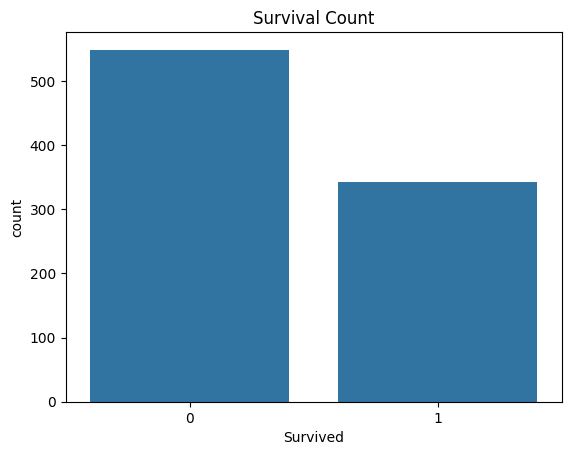

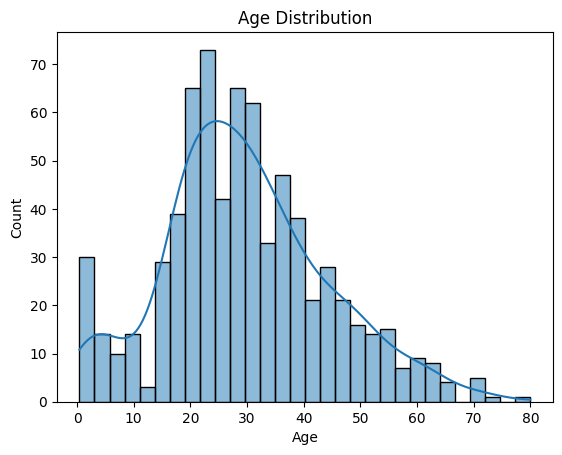

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()


sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.show()


In [15]:
"""
Observation:

The majority of passengers did not survive (Survived = 0).

There is a noticeable class imbalance which should be considered in further analysis or model training.#
"""

'\nObservation:\n\nThe majority of passengers did not survive (Survived = 0).\n\nThere is a noticeable class imbalance which should be considered in further analysis or model training.#\n'

In [17]:
"""
Observation:

Most passengers were aged between 20 and 40.

There are passengers of all ages, including children and older adults.

The distribution is slightly right-skewed, meaning more younger passengers.
"""

'\nObservation:\n\nMost passengers were aged between 20 and 40.\n\nThere are passengers of all ages, including children and older adults.\n\nThe distribution is slightly right-skewed, meaning more younger passengers.\n'

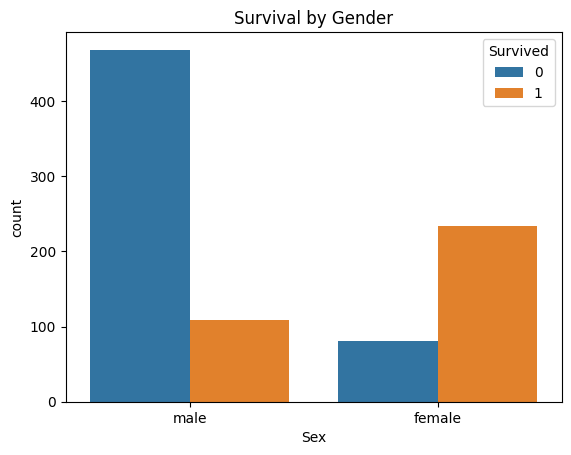

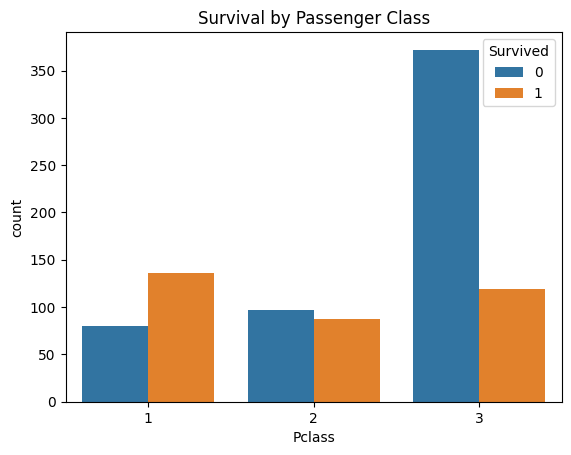

In [ ]:

sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()


sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()


In [20]:
"""
Observation:

Females had a much higher survival rate than males.

Males were more likely to die, indicating a possible "women and children first" evacuation strategy.
"""

'\nObservation:\n\nFemales had a much higher survival rate than males.\n\nMales were more likely to die, indicating a possible "women and children first" evacuation strategy.\n'

In [22]:
"""
Observation:

1st class passengers had the highest survival rate.

Survival rate decreases with class: 1st > 2nd > 3rd.

3rd class had the highest number of deaths.

"""

'\nObservation:\n\n1st class passengers had the highest survival rate.\n\nSurvival rate decreases with class: 1st > 2nd > 3rd.\n\n3rd class had the highest number of deaths.\n\n'

In [23]:
"""
Observation:

1st class passengers paid the highest fares, with some extreme outliers.

Fare decreases as passenger class decreases.

This supports the trend that higher-paying passengers had better survival chances.
"""

'\nObservation:\n\n1st class passengers paid the highest fares, with some extreme outliers.\n\nFare decreases as passenger class decreases.\n\nThis supports the trend that higher-paying passengers had better survival chances.\n'

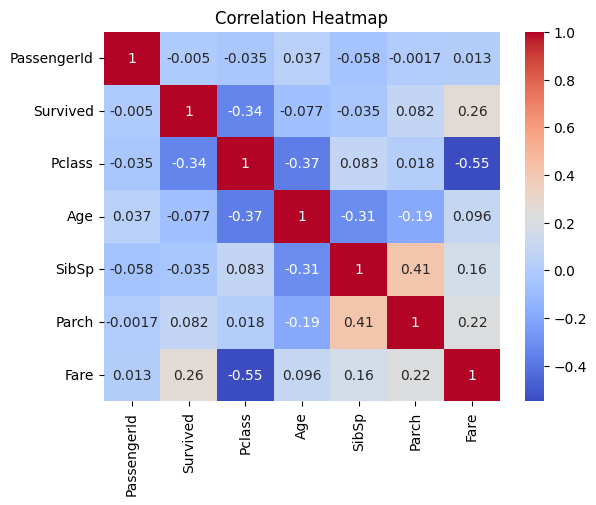

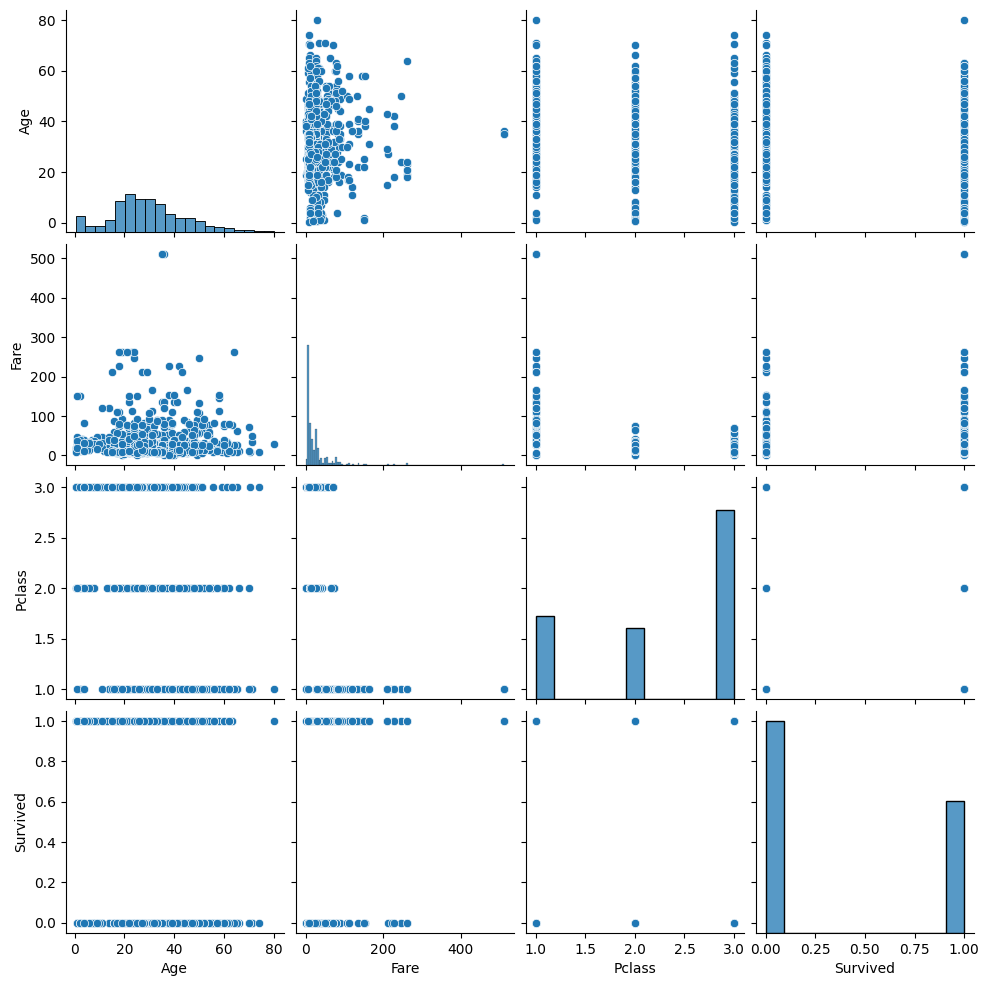

In [ ]:

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']])
plt.show()


In [28]:
"""
Observation:

Survivors tend to cluster in higher Fare and lower Pclass regions.

Many high-Fare passengers in 1st class survived.

Younger passengers were spread across classes, but age didn’t have a very strong direct impact on survival without other features.
"""

'\nObservation:\n\nSurvivors tend to cluster in higher Fare and lower Pclass regions.\n\nMany high-Fare passengers in 1st class survived.\n\nYounger passengers were spread across classes, but age didn’t have a very strong direct impact on survival without other features.\n'

In [25]:
"""
Observation:

Fare and Pclass have a moderate negative correlation (higher class, lower fare).

Pclass and Survived have a negative correlation — lower class (higher number) means lower survival.

SibSp and Parch show slight positive correlation, suggesting families often traveled together.
"""

'\nObservation:\n\nFare and Pclass have a moderate negative correlation (higher class, lower fare).\n\nPclass and Survived have a negative correlation — lower class (higher number) means lower survival.\n\nSibSp and Parch show slight positive correlation, suggesting families often traveled together.\n'

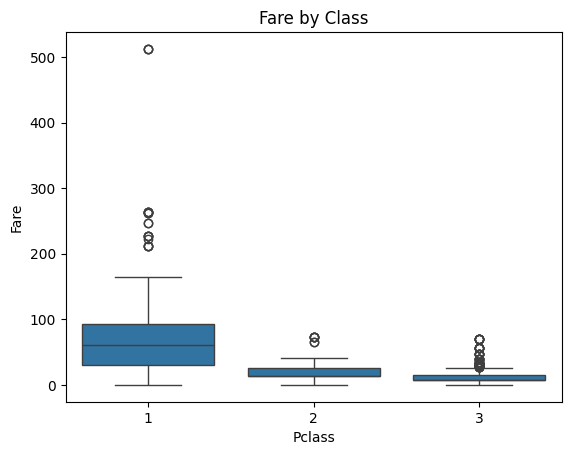

In [11]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare by Class')
plt.show()


In [26]:
"""
Observation:

1st class passengers paid the highest fares, with some extreme outliers.

Fare decreases as passenger class decreases.

This supports the trend that higher-paying passengers had better survival chances.
"""

'\nObservation:\n\n1st class passengers paid the highest fares, with some extreme outliers.\n\nFare decreases as passenger class decreases.\n\nThis supports the trend that higher-paying passengers had better survival chances.\n'

In [29]:
"""
Summary of Findings
Gender and Survival: Female passengers had a significantly higher survival rate compared to males.

Class and Survival: 1st class passengers were more likely to survive, while 3rd class had the most casualties.

Fare: Higher fare generally indicated a better chance of survival, likely due to association with higher class.

Age Distribution: Most passengers were between 20–40 years old. Age alone didn’t strongly determine survival but may play a role in combination with other factors.

Correlation Analysis: Pclass, Fare, and Sex showed notable relationships with survival. Correlation between other features was generally weak.

Family Size: SibSp and Parch suggested that people often traveled with family. A small family (1–2 people) might have increased survival chances, but large families did not.

Outliers: The Fare column had notable outliers, especially in 1st class, indicating a few very high-paying passengers.
"""

'\nSummary of Findings\nGender and Survival: Female passengers had a significantly higher survival rate compared to males.\n\nClass and Survival: 1st class passengers were more likely to survive, while 3rd class had the most casualties.\n\nFare: Higher fare generally indicated a better chance of survival, likely due to association with higher class.\n\nAge Distribution: Most passengers were between 20–40 years old. Age alone didn’t strongly determine survival but may play a role in combination with other factors.\n\nCorrelation Analysis: Pclass, Fare, and Sex showed notable relationships with survival. Correlation between other features was generally weak.\n\nFamily Size: SibSp and Parch suggested that people often traveled with family. A small family (1–2 people) might have increased survival chances, but large families did not.\n\nOutliers: The Fare column had notable outliers, especially in 1st class, indicating a few very high-paying passengers.\n'